# Diffusion Models — DDPM from Scratch on MNIST

**Author:** Shivani Bokka
**Dataset:** MNIST digits (28×28 grayscale)
**Goal:** Build a Denoising Diffusion Probabilistic Model (DDPM) end-to-end — the family of models behind Stable Diffusion, DALL·E 2, and Midjourney — and understand every moving part.

---

## What Is This Notebook About?

Notebook 05 covered **VAEs and GANs** — the previous generation of generative models. This notebook covers **diffusion models**, which have largely replaced GANs for high-quality image generation since 2021. If notebook 05 is where generative modeling *was*, this is where it *is now*.

We build a **DDPM** from scratch: the forward noising process, the noise schedule, a small U-Net that learns to denoise, the training loop, and the reverse sampling process that turns pure noise into digits. Every section explains the idea in plain language before the code, and every chart has its own "how to read this" guide.

---

## The One-Sentence Idea

> **Slowly destroy an image by adding noise step by step, then train a neural network to reverse one step of that process — and you can generate new images by starting from pure noise and running the reversal many times.**

That's it. The rest is making that precise.

---

## Forward vs Reverse Process

- **Forward process (fixed, no learning):** take a real image and add a little Gaussian noise, repeatedly, over `T` steps. After enough steps the image is indistinguishable from pure random noise. We don't learn this — it's a fixed recipe.
- **Reverse process (learned):** train a network to look at a noisy image and predict the noise that was added. If you can predict the noise, you can subtract a bit of it and step *back* toward a clean image. Run this from pure noise and a realistic image emerges.

---

## Topics Covered

| # | Section | Key Idea |
|---|---------|----------|
| 1 | Imports and Setup | Libraries, seeds, device |
| 2 | The Noise Schedule | Betas, alphas, cumulative alpha-bars |
| 3 | Forward Process | Add noise to a real digit and watch it dissolve |
| 4 | The Denoising U-Net | Small time-conditioned network |
| 5 | Training Loop | Predict the noise, minimize MSE |
| 6 | Sampling | Reverse the process from pure noise |
| 7 | Denoising Trajectory | Watch a digit emerge step by step |
| 8 | VAE vs GAN vs Diffusion | When to use what |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['image.cmap'] = 'gray'

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {device}")
if torch.cuda.is_available():
    print(f"GPU name        : {torch.cuda.get_device_name(0)}")


PyTorch version : 2.5.1+cu121
Device          : cuda
GPU name        : NVIDIA GeForce RTX 4060 Laptop GPU




---
## Section 2 — The Noise Schedule

The forward process adds noise in `T` steps. How *much* noise per step is controlled by a **variance schedule** $\beta_1, \dots, \beta_T$. We use the original DDPM linear schedule from $\beta_1 = 10^{-4}$ to $\beta_T = 0.02$.

Two derived quantities do all the work:

- $\alpha_t = 1 - \beta_t$ — how much *signal* survives one step.
- $\bar\alpha_t = \prod_{s=1}^{t} \alpha_s$ — how much signal survives from the start up to step $t$.

The magic identity (why DDPM is efficient) is that you can jump to **any** noise level $t$ in one shot, without looping:

$$x_t = \sqrt{\bar\alpha_t}\, x_0 + \sqrt{1 - \bar\alpha_t}\, \epsilon, \qquad \epsilon \sim \mathcal{N}(0, I)$$


alpha_bar[0]   = 0.9999  (almost all signal)
alpha_bar[T-1] = 0.0481  (almost all noise)


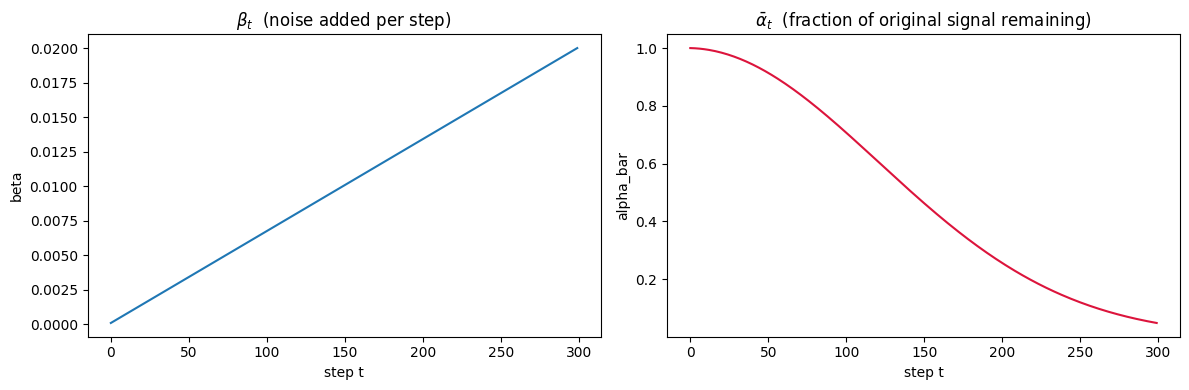

In [2]:
T = 300  # number of diffusion steps (small T keeps MNIST fast; papers use 1000)

betas = torch.linspace(1e-4, 0.02, T)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

# Sanity checks: alpha_bar must start near 1 (little noise) and decay toward 0 (all noise)
assert alpha_bars[0] > 0.99, "alpha_bar should start near 1"
assert alpha_bars[-1] < alpha_bars[0], "alpha_bar must be monotonically decreasing"
print(f"alpha_bar[0]   = {alpha_bars[0]:.4f}  (almost all signal)")
print(f"alpha_bar[T-1] = {alpha_bars[-1]:.4f}  (almost all noise)")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(betas.numpy()); ax[0].set_title(r'$\beta_t$  (noise added per step)')
ax[0].set_xlabel('step t'); ax[0].set_ylabel('beta')
ax[1].plot(alpha_bars.numpy(), color='crimson')
ax[1].set_title(r'$\bar{\alpha}_t$  (fraction of original signal remaining)')
ax[1].set_xlabel('step t'); ax[1].set_ylabel('alpha_bar')
plt.tight_layout(); plt.show()


### How to Read This Chart: The Noise Schedule

- **Left ($\beta_t$):** the amount of fresh noise injected at each step. It grows linearly, so later steps corrupt the image faster than early ones.
- **Right ($\bar\alpha_t$):** the fraction of the *original* image that survives up to step $t$. It starts at ~1.0 (step 0 is basically the clean image) and decays smoothly toward 0 (the image has been completely replaced by noise).

The right curve is the important one: at $t \approx 0$ the network sees an almost-clean image, and near $t = T$ it sees almost-pure noise. Training exposes it to every point along this curve.


---


## Section 3 — The Forward Process

Let's actually watch a digit dissolve. Using the jump identity above, we noise a single MNIST image to several noise levels and display them.


Training images: 60000


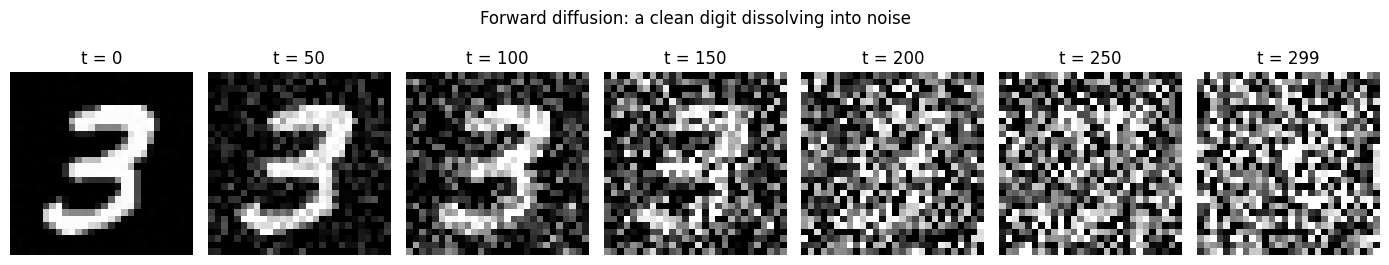

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),  # map [0,1] -> [-1,1], the DDPM convention
])
train_ds = torchvision.datasets.MNIST(root='data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=0)
print(f"Training images: {len(train_ds)}")

def q_sample(x0, t, noise):
    # Forward process: jump straight to noise level t. x0:[B,1,28,28], t:[B].
    ab = alpha_bars.to(x0.device)[t].view(-1, 1, 1, 1)
    return torch.sqrt(ab) * x0 + torch.sqrt(1 - ab) * noise

# Visualize one digit at increasing noise levels
x0, _ = train_ds[7]
x0 = x0.unsqueeze(0)
steps_to_show = [0, 50, 100, 150, 200, 250, 299]
fig, axes = plt.subplots(1, len(steps_to_show), figsize=(14, 2.5))
for ax, t in zip(axes, steps_to_show):
    noise = torch.randn_like(x0)
    xt = q_sample(x0, torch.tensor([t]), noise)
    ax.imshow(xt.squeeze().numpy(), vmin=-1, vmax=1)
    ax.set_title(f't = {t}'); ax.axis('off')
plt.suptitle('Forward diffusion: a clean digit dissolving into noise', y=1.05)
plt.tight_layout(); plt.show()


### How to Read This Chart: Forward Diffusion

Left to right, the same digit at increasing noise levels $t$.

- At **t = 0** you see the original digit (a clean "0").
- By **t ≈ 150** the digit is heavily corrupted but still faintly visible.
- By **t = 299** it is indistinguishable from random static — exactly the pure-noise state our sampler will start from.

The network's job is to reverse this: given any frame here, predict the noise that was added so we can step one image to the left.


---


## Section 4 — The Denoising U-Net

The network takes a noisy image $x_t$ **and** the timestep $t$, and predicts the noise $\epsilon$. It must know $t$ because "how much noise to remove" depends on where we are in the schedule.

We use a compact **U-Net**: a downsampling path, a bottleneck, and an upsampling path with skip connections. The timestep is turned into a **sinusoidal embedding** (same trick as positional encodings in notebook 04) and injected into each block. This is deliberately small so it trains in minutes on MNIST and later exports cleanly to ONNX for the web demo.


In [4]:
def timestep_embedding(t, dim):
    # Sinusoidal embedding of the (integer) timestep -- like Transformer positional encoding.
    half = dim // 2
    freqs = torch.exp(-np.log(10000) * torch.arange(half, device=t.device) / half)
    args = t[:, None].float() * freqs[None]
    return torch.cat([torch.cos(args), torch.sin(args)], dim=-1)

class Block(nn.Module):
    def __init__(self, in_ch, out_ch, temb_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.temb = nn.Linear(temb_dim, out_ch)
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)

    def forward(self, x, temb):
        h = F.silu(self.norm1(self.conv1(x)))
        h = h + self.temb(temb)[:, :, None, None]   # inject time
        h = F.silu(self.norm2(self.conv2(h)))
        return h

class UNet(nn.Module):
    # Small U-Net for 28x28 single-channel images.
    def __init__(self, base=32, temb_dim=128):
        super().__init__()
        self.temb_dim = temb_dim
        self.temb_mlp = nn.Sequential(nn.Linear(temb_dim, temb_dim), nn.SiLU(),
                                      nn.Linear(temb_dim, temb_dim))
        self.down1 = Block(1, base, temb_dim)
        self.down2 = Block(base, base * 2, temb_dim)
        self.pool = nn.MaxPool2d(2)
        self.mid = Block(base * 2, base * 2, temb_dim)
        self.up2 = Block(base * 2 + base * 2, base, temb_dim)
        self.up1 = Block(base + base, base, temb_dim)
        self.out = nn.Conv2d(base, 1, 1)

    def forward(self, x, t):
        temb = self.temb_mlp(timestep_embedding(t, self.temb_dim))
        d1 = self.down1(x, temb)            # 28
        d2 = self.down2(self.pool(d1), temb)  # 14
        m = self.mid(self.pool(d2), temb)     # 7
        u2 = F.interpolate(m, scale_factor=2, mode='nearest')  # 14
        u2 = self.up2(torch.cat([u2, d2], dim=1), temb)
        u1 = F.interpolate(u2, scale_factor=2, mode='nearest')  # 28
        u1 = self.up1(torch.cat([u1, d1], dim=1), temb)
        return self.out(u1)

model = UNet().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"U-Net parameters: {n_params:,}")

# Shape sanity check
_x = torch.randn(4, 1, 28, 28, device=device)
_t = torch.randint(0, T, (4,), device=device)
assert model(_x, _t).shape == _x.shape, "U-Net output shape must match input"
print("Shape check passed:", tuple(model(_x, _t).shape))


U-Net parameters: 275,553


Shape check passed: (4, 1, 28, 28)




---
## Section 5 — Training Loop

The DDPM training objective is beautifully simple. For each image:

1. Pick a random timestep $t$.
2. Sample random noise $\epsilon$.
3. Make the noisy image $x_t$ using the jump identity.
4. Ask the network to predict $\epsilon$ from $(x_t, t)$.
5. Minimize the **mean squared error** between predicted and true noise.

That single MSE loss is the entire training signal — no adversarial game (like GANs), no KL term (like VAEs). This stability is a big reason diffusion overtook GANs.


In [5]:
EPOCHS = 20
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)

losses = []
start = time.time()
for epoch in range(EPOCHS):
    model.train()
    running = 0.0
    for x0, _ in train_loader:
        x0 = x0.to(device)
        t = torch.randint(0, T, (x0.size(0),), device=device)
        noise = torch.randn_like(x0)
        xt = q_sample(x0, t, noise)
        pred = model(xt, t)
        loss = F.mse_loss(pred, noise)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        running += loss.item() * x0.size(0)
    epoch_loss = running / len(train_ds)
    losses.append(epoch_loss)
    print(f"Epoch {epoch+1:2d}/{EPOCHS}  |  noise-MSE loss: {epoch_loss:.4f}")
print(f"\nTraining time: {time.time()-start:.1f}s")


Epoch  1/20  |  noise-MSE loss: 0.1273


Epoch  2/20  |  noise-MSE loss: 0.0645


Epoch  3/20  |  noise-MSE loss: 0.0576


Epoch  4/20  |  noise-MSE loss: 0.0539


Epoch  5/20  |  noise-MSE loss: 0.0522


...

Epoch 16/20  |  noise-MSE loss: 0.0443


Epoch 17/20  |  noise-MSE loss: 0.0440


Epoch 18/20  |  noise-MSE loss: 0.0438


Epoch 19/20  |  noise-MSE loss: 0.0434


Epoch 20/20  |  noise-MSE loss: 0.0431

Training time: 428.6s


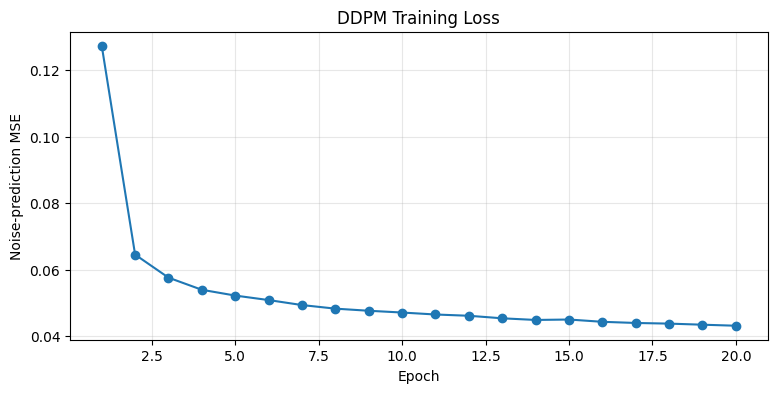

In [6]:
plt.figure(figsize=(9, 4))
plt.plot(range(1, EPOCHS + 1), losses, marker='o')
plt.xlabel('Epoch'); plt.ylabel('Noise-prediction MSE')
plt.title('DDPM Training Loss'); plt.grid(alpha=0.3)
plt.show()


### How to Read This Chart: DDPM Training Loss

A single, smoothly decreasing curve — this is what healthy diffusion training looks like, and it's a stark contrast to the oscillating adversarial curves in notebook 05's GAN section.

- The loss is the MSE between the network's **predicted noise** and the **actual noise** we added.
- It won't go to zero: at high $t$ the input is nearly pure noise and the true $\epsilon$ is genuinely hard to pin down, so a plateau is expected and fine.
- No mode collapse, no discriminator/generator balancing act — just steady descent. That reliability is diffusion's headline advantage.


---


## Section 6 — Sampling (the Reverse Process)

Now we generate. Start from pure noise $x_T \sim \mathcal{N}(0, I)$ and, for $t = T-1, \dots, 0$, use the network's noise prediction to take one step back toward a clean image, following the DDPM update rule:

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\epsilon_\theta(x_t, t)\right) + \sigma_t z$$

where $z \sim \mathcal{N}(0,I)$ for $t>0$ and $z=0$ for the final step.


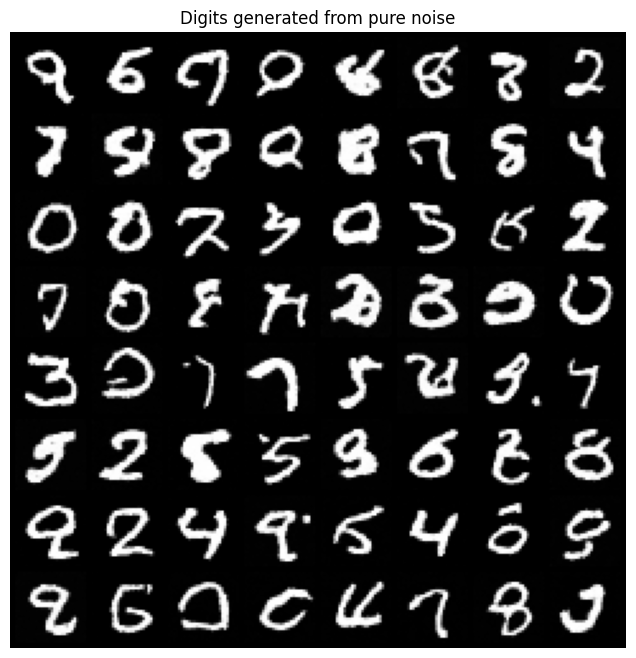

In [7]:
@torch.no_grad()
def sample(model, n, return_trajectory=False):
    model.eval()
    x = torch.randn(n, 1, 28, 28, device=device)
    a = alphas.to(device); ab = alpha_bars.to(device); b = betas.to(device)
    traj = []
    for t in reversed(range(T)):
        tt = torch.full((n,), t, device=device, dtype=torch.long)
        eps = model(x, tt)
        coef = b[t] / torch.sqrt(1 - ab[t])
        mean = (x - coef * eps) / torch.sqrt(a[t])
        if t > 0:
            x = mean + torch.sqrt(b[t]) * torch.randn_like(x)
        else:
            x = mean
        if return_trajectory and t % 30 == 0:
            traj.append(x.clamp(-1, 1).cpu())
    x = x.clamp(-1, 1)
    return (x, traj) if return_trajectory else x

samples = sample(model, 64)
grid = torchvision.utils.make_grid(samples, nrow=8, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.title('Digits generated from pure noise'); plt.axis('off')
plt.show()


### How to Read This Chart: Generated Digits

An 8×8 grid of digits the model **invented** — none of these are training images. Each one started as a different patch of random static and was denoised 300 steps into a digit.

Judge them on two axes:
- **Sharpness** — are strokes clean or blurry? A small U-Net and only 20 epochs will leave some fuzz; that's expected.
- **Diversity** — do you see a range of digit classes, not the same one repeated? Diversity here is the direct answer to the **mode collapse** you saw plague GANs in notebook 05. Diffusion models essentially never mode-collapse.


---


## Section 7 — The Denoising Trajectory

The single most intuitive picture in all of diffusion: watch one sample walk from pure noise to a finished digit.


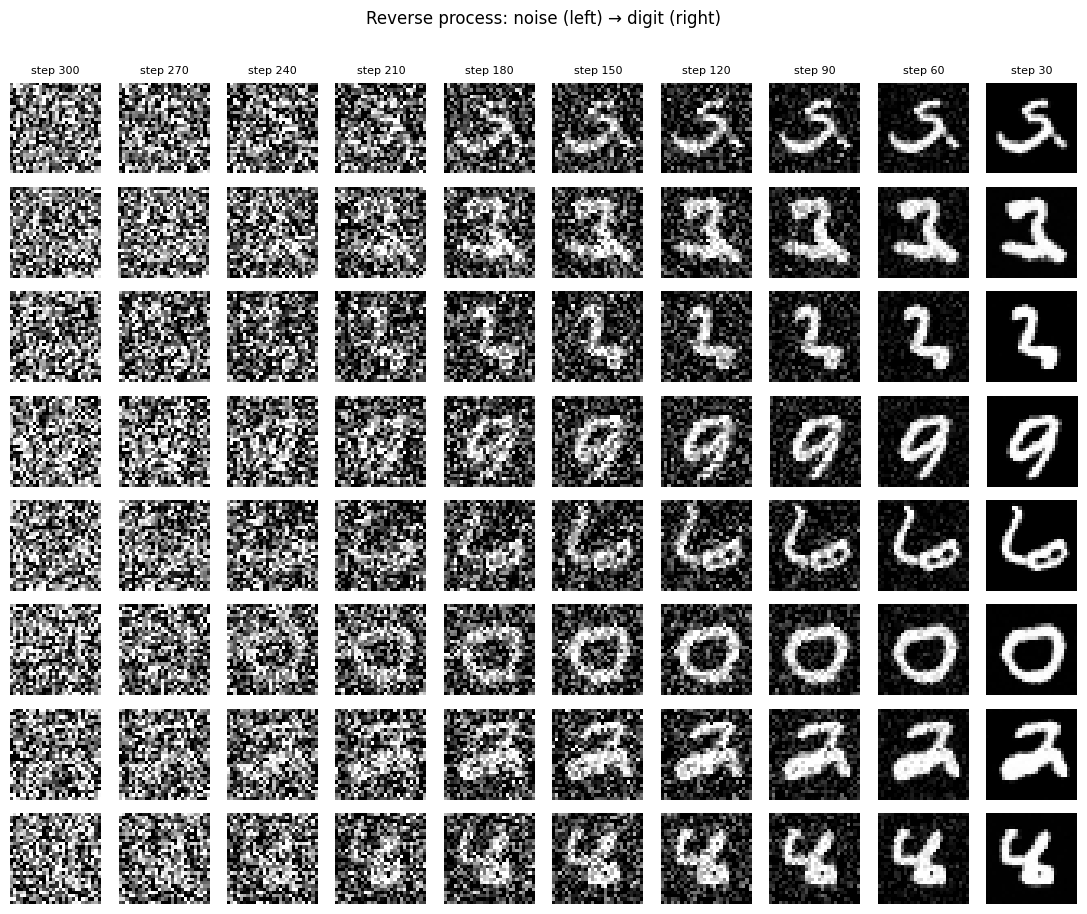

In [8]:
_, traj = sample(model, 8, return_trajectory=True)
# traj holds snapshots every 30 steps, from noisy -> clean
n_snaps = len(traj)
fig, axes = plt.subplots(8, n_snaps, figsize=(n_snaps * 1.1, 9))
for row in range(8):
    for col, snap in enumerate(traj):
        axes[row, col].imshow(snap[row].squeeze().numpy(), vmin=-1, vmax=1)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(f'step {T - col*30}', fontsize=8)
plt.suptitle('Reverse process: noise (left) → digit (right)', y=1.01)
plt.tight_layout(); plt.show()


### How to Read This Chart: The Denoising Trajectory

Each **row** is one sample; reading **left to right** is time running backward through the diffusion process.

- The **leftmost column** is near-pure noise (high $t$).
- Moving right, coarse blobs appear first, then the network commits to a digit identity, then sharpens the strokes.
- The **rightmost column** is the finished sample.

Notice the digit's *identity* is decided fairly early and only refined afterward — the model roughs out "this will be a 7" before it cleans up the edges. This coarse-to-fine behavior is characteristic of diffusion sampling.


---


## Section 8 — VAE vs GAN vs Diffusion

You've now built all three major families of generative model across notebooks 05 and 06. Here's how they compare.

| | **VAE** (nb 05) | **GAN** (nb 05) | **Diffusion** (this nb) |
|---|---|---|---|
| **Training signal** | Reconstruction + KL | Adversarial min-max | Noise-prediction MSE |
| **Training stability** | Very stable | Fragile (mode collapse, balance) | Very stable |
| **Sample quality** | Blurry | Sharp | Sharp, state-of-the-art |
| **Sampling speed** | 1 forward pass (fast) | 1 forward pass (fast) | Many steps (slow) |
| **Mode coverage** | Good | Can collapse | Excellent |
| **Powers today** | Representation learning | (largely superseded) | Stable Diffusion, DALL·E, Imagen |

**The tradeoff in one line:** diffusion buys the best quality *and* the best stability, and pays for it with slow, iterative sampling. Most modern research (DDIM, latent diffusion, distillation) is about making that sampling faster.

---

## Key Takeaways

1. **The forward process is fixed noise; only the reverse denoiser is learned.**
2. **The training objective is a plain MSE on predicted noise** — no adversarial game, which is why it's so stable.
3. **The $\bar\alpha_t$ schedule lets you jump to any noise level in one step**, making training efficient.
4. **Sampling is iterative** — the quality/speed tradeoff that defines diffusion research.
5. **Diffusion doesn't mode-collapse**, directly fixing the biggest weakness of the GANs in notebook 05.
